# Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

X_train_val = pd.read_csv('Data/pirate_pain_train.csv')
y_train_val = pd.read_csv('Data/pirate_pain_train_labels.csv')
X_test = pd.read_csv('Data/pirate_pain_test.csv')


In [3]:
X_train_val.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [4]:
X_train_val.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202051,0.197608,0.295605,0.300787,...,4.974496e-03,5.472244e-03,1.235450e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746147e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,2.800090e-06,3.079465e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


In [5]:
survey_cols = ["pain_survey_1", "pain_survey_2", "pain_survey_3", "pain_survey_4"]
body_cols   = ["n_eyes"]
cont_cols   = [c for c in X_train_val.columns if c.startswith("joint_")]
time_cols = ["time"]

In [6]:
def find_outliers_iqr(df, cols):
    outlier_indices = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_indices[col] = df.index[mask].tolist()
    return outlier_indices

iqr_outliers = find_outliers_iqr(X_train_val, cont_cols)

for col, idx in iqr_outliers.items():
    print(f"{col}: {len(idx)} outliers")

joint_00: 1880 outliers
joint_01: 2772 outliers
joint_02: 0 outliers
joint_03: 0 outliers
joint_04: 0 outliers
joint_05: 0 outliers
joint_06: 12585 outliers
joint_07: 9904 outliers
joint_08: 124 outliers
joint_09: 4679 outliers
joint_10: 22 outliers
joint_11: 5 outliers
joint_12: 2116 outliers
joint_13: 14171 outliers
joint_14: 13823 outliers
joint_15: 12118 outliers
joint_16: 11600 outliers
joint_17: 10006 outliers
joint_18: 10461 outliers
joint_19: 12578 outliers
joint_20: 12316 outliers
joint_21: 13739 outliers
joint_22: 13247 outliers
joint_23: 14800 outliers
joint_24: 14253 outliers
joint_25: 16677 outliers
joint_26: 9155 outliers
joint_27: 8512 outliers
joint_28: 8753 outliers
joint_29: 6653 outliers
joint_30: 0 outliers


In [7]:
# Classes are really unbalanced 

print(y_train_val['label'].value_counts())
print(y_train_val['label'].value_counts(normalize=True))


label
no_pain      511
low_pain      94
high_pain     56
Name: count, dtype: int64
label
no_pain      0.773071
low_pain     0.142209
high_pain    0.084720
Name: proportion, dtype: float64


In [8]:
print(X_train_val['n_hands'].value_counts())
print(X_test['n_hands'].value_counts())
print(X_train_val['n_eyes'].value_counts())
print(X_test['n_eyes'].value_counts())
print(X_train_val['n_legs'].value_counts())
print(X_test['n_legs'].value_counts())

n_hands
two              104800
one+hook_hand       960
Name: count, dtype: int64
n_hands
two              209760
one+hook_hand      2080
Name: count, dtype: int64
n_eyes
two              104800
one+eye_patch       960
Name: count, dtype: int64
n_eyes
two              209760
one+eye_patch      2080
Name: count, dtype: int64
n_legs
two            104800
one+peg_leg       960
Name: count, dtype: int64
n_legs
two            209760
one+peg_leg      2080
Name: count, dtype: int64


In [9]:
# Body features look suspiciously correlated -> one-hot encode them

onehot_encoded_eyes = pd.get_dummies(X_train_val['n_eyes'], prefix='n_eyes').astype(float)
onehot_encoded_test_eyes= pd.get_dummies(X_test['n_eyes'], prefix='n_eyes').astype(float)

onehot_encoded_hands = pd.get_dummies(X_train_val['n_hands'], prefix='n_hands').astype(float)
onehot_encoded_test_hands= pd.get_dummies(X_test['n_hands'], prefix='n_hands').astype(float)

onehot_encoded_legs = pd.get_dummies(X_train_val['n_legs'], prefix='n_legs').astype(float)
onehot_encoded_test_legs= pd.get_dummies(X_test['n_legs'], prefix='n_legs').astype(float)


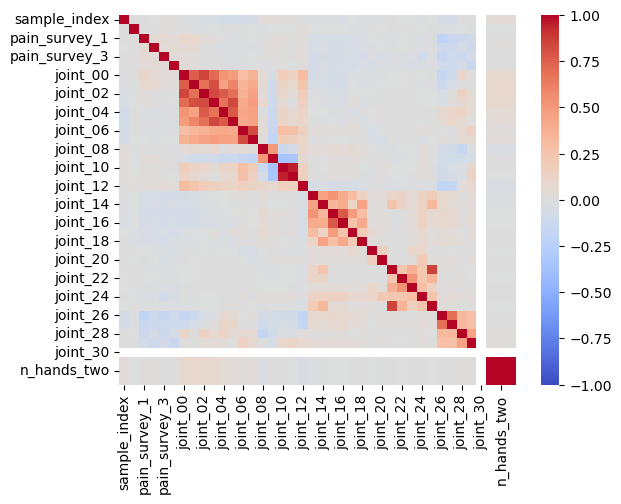

In [10]:
# Correlation matrix to get a sense of the general correlation maong features 

X_train_val = pd.concat([X_train_val, onehot_encoded_eyes], axis=1)
X_test = pd.concat([X_test, onehot_encoded_test_eyes], axis=1)
X_train_val.drop('n_eyes', axis=1, inplace=True)
X_test.drop('n_eyes', axis=1, inplace=True)
X_train_val.drop('n_eyes_one+eye_patch', axis=1, inplace=True)
X_test.drop('n_eyes_one+eye_patch', axis=1, inplace=True)

X_train_val = pd.concat([X_train_val, onehot_encoded_hands], axis=1)
X_test = pd.concat([X_test, onehot_encoded_test_hands], axis=1)
X_train_val.drop('n_hands', axis=1, inplace=True)
X_test.drop('n_hands', axis=1, inplace=True)
X_train_val.drop('n_hands_one+hook_hand', axis=1, inplace=True)
X_test.drop('n_hands_one+hook_hand', axis=1, inplace=True)

X_train_val = pd.concat([X_train_val, onehot_encoded_legs], axis=1)
X_test = pd.concat([X_test, onehot_encoded_test_legs], axis=1)
X_train_val.drop('n_legs', axis=1, inplace=True)
X_test.drop('n_legs', axis=1, inplace=True)
X_train_val.drop('n_legs_one+peg_leg', axis=1, inplace=True)
X_test.drop('n_legs_one+peg_leg', axis=1, inplace=True)

correlation_mat = X_train_val.corr()
sns.heatmap(correlation_mat, annot = False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12']


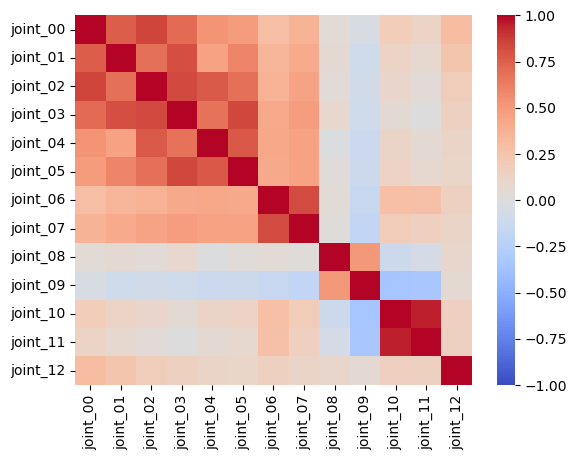

In [11]:
cols = [f'joint_{str(i).zfill(2)}' for i in range(13)] 
print(cols) # joint00 to joint12
correlation_mat = X_train_val[cols].corr()

# Plot the heatmap
sns.heatmap(correlation_mat, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

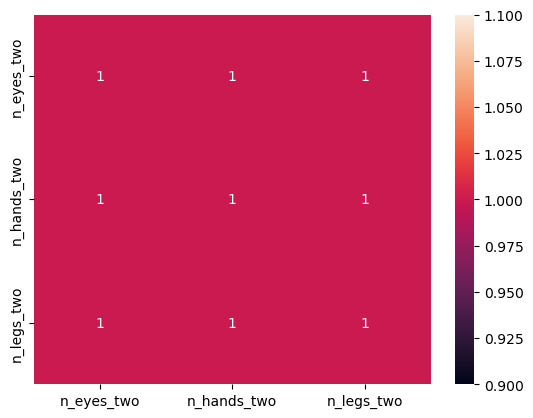

In [12]:
df_body = X_train_val.copy()

df_body = df_body[[ 'n_eyes_two', 'n_hands_two', 'n_legs_two']]

df_body.head()
correlation_mat = df_body.corr()
sns.heatmap(correlation_mat, annot = True)
plt.show()

Number of users: 661


/var/folders/b8/rzcf55796dx0l9hv3jf_nxnr0000gn/T/ipykernel_88026/1131077017.py:13: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.countplot(


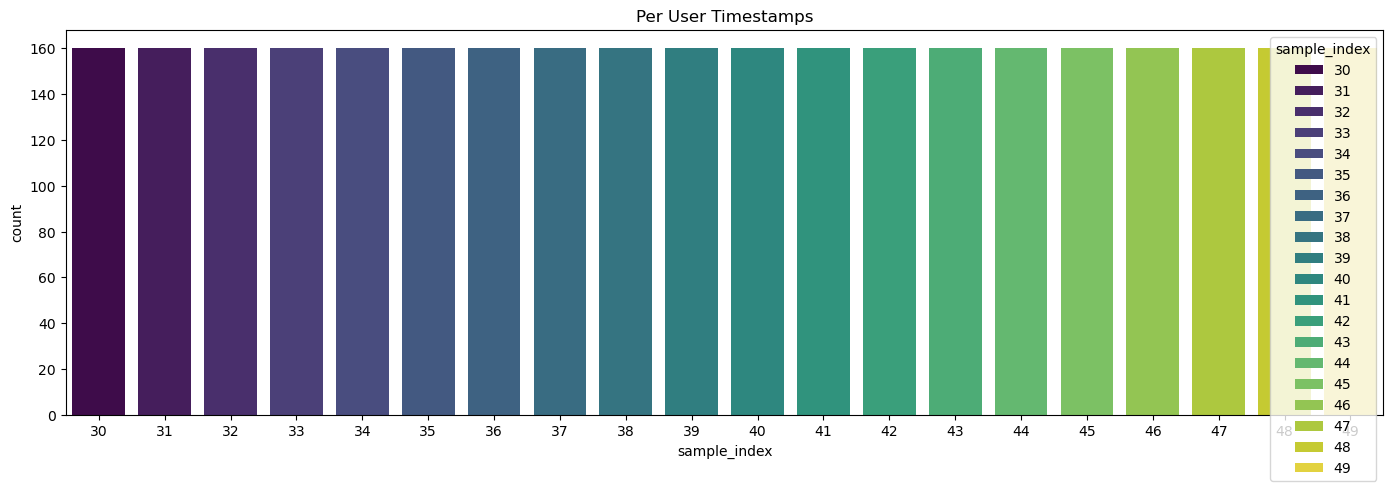

In [13]:
# Count the number of unique users

n_users = len(X_train_val['sample_index'].unique())
print(f'Number of users: {n_users}')

n = 20  # Number of users to visualise

# Create a custom colour map with distinct colours for each user
colors = plt.cm.viridis(np.linspace(0, 1, n))

# Visualize the count of timestamps for each user
plt.figure(figsize=(17, 5))
sns.countplot(
    x='sample_index',
    data=X_train_val[X_train_val['sample_index'].isin(range(30, 50))],
    palette=colors,
    hue='sample_index'
    
)

# Set the title of the plot
plt.title('Per User Timestamps')

# Display the plot
plt.show()

In [14]:
# Get all unique users
unique_users = X_train_val['sample_index'].unique()

# For each user, count the number of timestamps and assert it equals 160
for user in unique_users:
    timestamp_count = len(X_train_val[X_train_val['sample_index'] == user])
    if timestamp_count != 160:
        print(f"User {user} has {timestamp_count} timestamps, expected 160")



In [15]:
# Remove the user with NaN value from X_train_val
print(f"Shape before removing NaN users: {X_train_val.shape}")

X_train_val = X_train_val[X_train_val['sample_index'].notna()]

print(f"Shape after removing NaN users: {X_train_val.shape}")

Shape before removing NaN users: (105760, 40)
Shape after removing NaN users: (105760, 40)


In [16]:
# Retry
# Get all unique users
unique_users = X_train_val['sample_index'].unique()

# For each user, count the number of timestamps and assert it equals 160
for user in unique_users:
    timestamp_count = len(X_train_val[X_train_val['sample_index'] == user])
    assert timestamp_count == 160, f"User {user} has {timestamp_count} timestamps, expected 160"

print(f"All {len(unique_users)} users have exactly 160 timestamps")

All 661 users have exactly 160 timestamps


In [17]:
# Check if y_train_val contains all users from X_train_val
users_in_X = set(X_train_val['sample_index'].unique())
users_in_y = set(y_train_val['sample_index'].unique())

print(f"Number of unique users in X_train_val: {len(users_in_X)}")
print(f"Number of unique users in y_train_val: {len(users_in_y)}")

# Check if all users in X are in y
all_users_present = users_in_X == users_in_y

if all_users_present:
    print("\nAll users in X_train_val have labels in y_train_val")

Number of unique users in X_train_val: 661
Number of unique users in y_train_val: 661

All users in X_train_val have labels in y_train_val


In [18]:
# Check if all sample_index values in y_train_val are unique
is_unique = y_train_val['sample_index'].is_unique

print(f"Are all sample_index values unique? {is_unique}")
print(f"Total rows: {len(y_train_val)}")
print(f"Unique sample_index values: {y_train_val['sample_index'].nunique()}")

# Check for duplicates
duplicates = y_train_val[y_train_val['sample_index'].duplicated(keep=False)]
if len(duplicates) > 0:
    print(f"\nFound {len(duplicates)} duplicate entries:")
    print(duplicates.sort_values('sample_index'))
else:
    print("\nNo duplicates found - each user appears exactly once")

Are all sample_index values unique? True
Total rows: 661
Unique sample_index values: 661

No duplicates found - each user appears exactly once


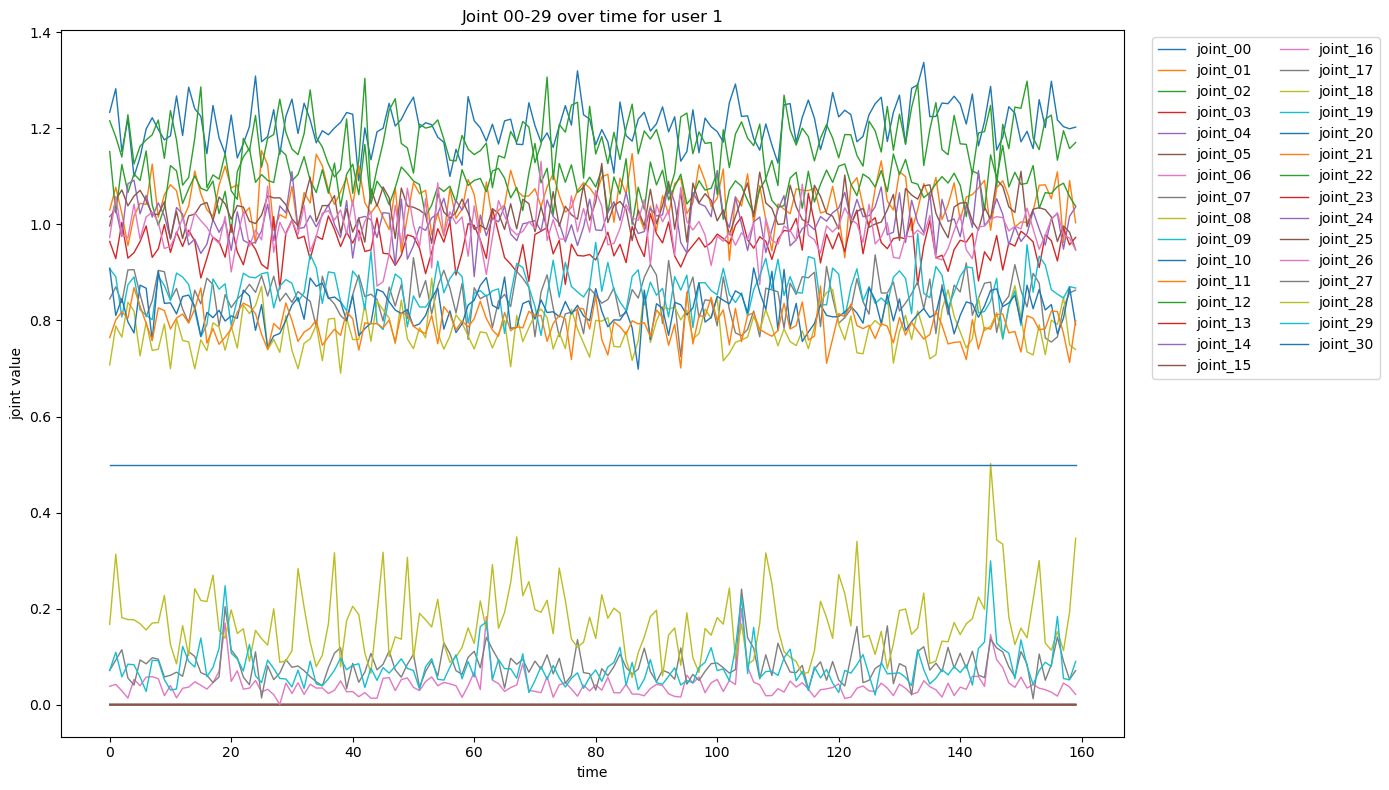

In [19]:
user_id = 1
joint_cols = [f"joint_{i:02d}" for i in range(31)]

df_user = X_train_val.loc[X_train_val["sample_index"] == user_id, ["time"] + joint_cols].sort_values("time")

if df_user.empty:
    print(f"No data for sample_index == {user_id}")
else:
    plt.figure(figsize=(14, 8))
    for col in joint_cols:
        plt.plot(df_user["time"], df_user[col], label=col, linewidth=1)
    plt.xlabel("time")
    plt.ylabel("joint value")
    plt.title(f"Joint 00-29 over time for user {user_id}")
    plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

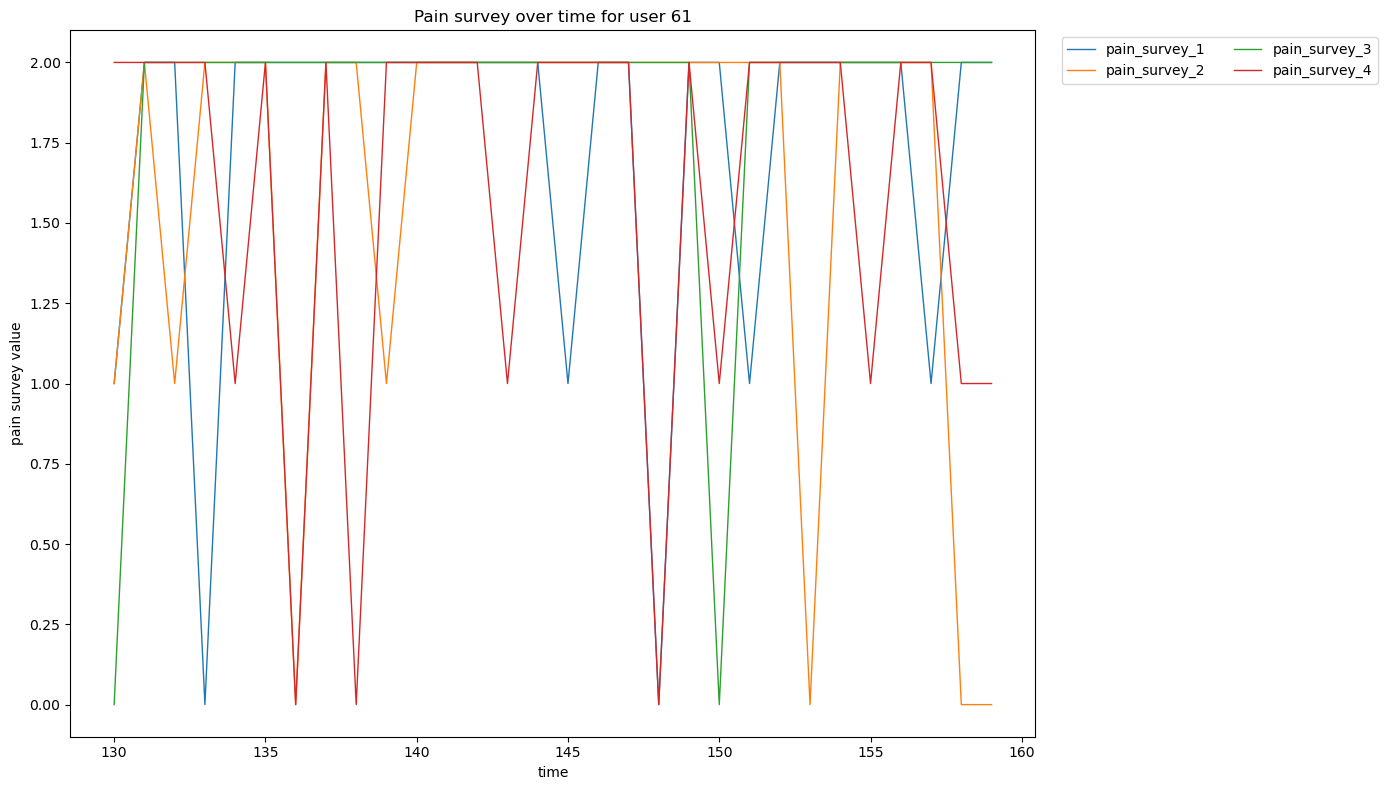

In [20]:
user_id = 61
joint_cols = [f"pain_survey_{i:01d}" for i in range(1, 5)]

df_user = X_train_val.loc[X_train_val["sample_index"] == user_id, ["time"] + joint_cols].sort_values("time")

if df_user.empty:
    print(f"No data for sample_index == {user_id}")
else:
    plt.figure(figsize=(14, 8))
    for col in joint_cols:
        plt.plot(df_user["time"][-30:], df_user[col][-30:], label=col, linewidth=1)
    plt.xlabel("time")
    plt.ylabel("pain survey value")
    plt.title(f"Pain survey over time for user {user_id}")
    plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [21]:
X_train_val["sample_index"] = X_train_val["sample_index"].astype(str)
print(type(X_train_val["sample_index"].values[0]))
survey_values = X_train_val.loc[X_train_val["sample_index"] == '43', survey_cols].values
print(survey_values[155:160, :])

X_train_val["sample_index"] = X_train_val["sample_index"].astype(str)
print(type(X_train_val["sample_index"].values[0]))
survey_values = X_train_val.loc[X_train_val["sample_index"] == '86', survey_cols].values
print(survey_values[155:160, :])

X_train_val["sample_index"] = X_train_val["sample_index"].astype(str)
print(type(X_train_val["sample_index"].values[0]))
survey_values = X_train_val.loc[X_train_val["sample_index"] == '88', survey_cols].values
print(survey_values[155:160, :])

<class 'str'>
[[2 2 0 2]
 [2 2 2 0]
 [0 2 2 2]
 [2 2 1 2]
 [2 2 1 0]]
<class 'str'>
[[2 2 0 1]
 [2 2 2 2]
 [2 2 2 2]
 [2 2 2 1]
 [1 2 2 1]]
<class 'str'>
[[2 2 2 2]
 [0 1 2 2]
 [0 0 0 0]
 [2 2 1 0]
 [2 2 1 1]]
